# Cluster maps

In [1]:
import fitsio
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table, setdiff
import pyccl as ccl
from ulid import ULID

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Opening file

In [87]:
output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
outputfile = output_path + sufix + '.fits'

data = fitsio.FITS(outputfile)
data


  file: Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.fits
  mode: READONLY
  extnum hdutype         hduname[v]
  0      IMAGE_HDU       
  1      BINARY_TBL      MAPS
  2      BINARY_TBL      FIT_NUMPY
  3      BINARY_TBL      FIT_MINUIT

## Study of numpy method

It is the chatGPT version, using matrix invertion and numpy tools.

In [4]:
dfNumpy = Table(data['FIT_NUMPY'].read()).to_pandas()
dfNumpy

,Map_ID,A,Dx,Dy,Dz
0,01KNRHFD1J62D5NP0SRDEC0FCG,0.000687,-0.000474,0.000267,0.000419
1,01KNRHFD297TAFZ5Q68YCPK2VM,0.000387,0.000055,0.000302,-0.000236
2,01KNRHFD2XDEPBV818WS1J7RMY,0.000453,-0.000048,-0.000256,0.000370
3,01KNRHFD3RZE96226Y8AYCBX44,0.000285,-0.000273,-0.000040,-0.000074
4,01KNRHFD45ET7XHNHGDBBZBR7X,0.000539,0.000383,0.000317,0.000207
...,...,...,...,...,...
9995,01KNRNDH3XQBH45KSDSC0R5F6D,0.000975,-0.000548,-0.000262,0.000763
9996,01KNRNDH429YRKDE22FVY9116E,0.000413,0.000303,0.000272,0.000068
9997,01KNRNDH48V6ETZTZTZ9ZTNAGB,0.000845,0.000391,-0.000097,0.000743
9998,01KNRNDH4EG5WY64YG8PM658JB,0.000668,-0.000083,0.000518,0.000413


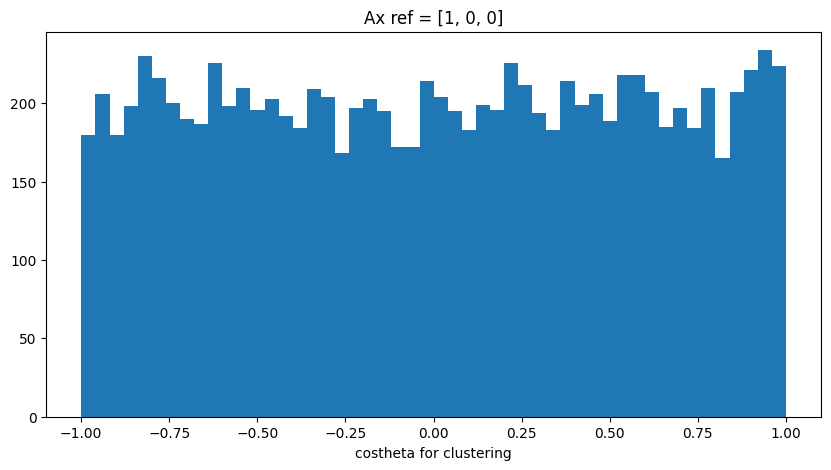

In [5]:
def get_costheta_cartesian(df, axref=[1, 0, 0]):
    data = df.copy()
    axref = np.array(axref)
    axref = axref/np.linalg.norm(axref)
    dip = np.array(data[['Dx', 'Dy', 'Dz']])
    return np.dot(dip, axref)/data['A']

axref = [1, 0, 0]
dfNumpy['costheta'] = dfNumpy.apply(get_costheta_cartesian, axis=1, args=(axref,))
col = 'costheta'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(dfNumpy[col], xlabel=f"{col} for clustering", bins=50, figax=(fig, ax), title=f"Ax ref = {axref}");

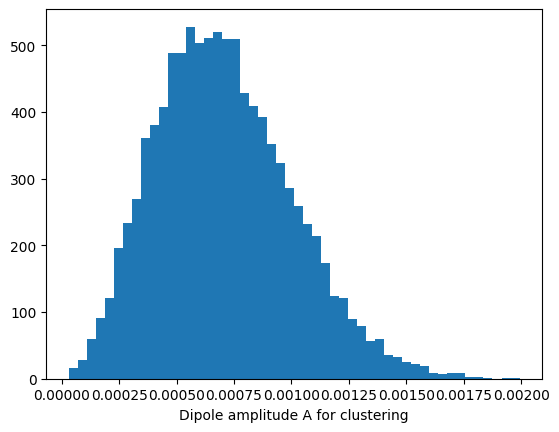

In [6]:
col = 'A'
fig, ax = plt.subplots()
get_hist(dfNumpy[col], xlabel=f"Dipole amplitude {col} for clustering", bins=50, figax=(fig, ax));

In [7]:
dfNumpy.describe()

,A,Dx,Dy,Dz,costheta
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,0.000707,0.000002,-7.693099e-07,-4.658319e-08,0.007257
std,0.000297,0.000446,4.402594e-04,4.428252e-04,0.581251
min,0.000030,-0.001693,-1.547497e-03,-1.713045e-03,-0.999241
25%,0.000489,-0.000304,-2.955812e-04,-3.017372e-04,-0.503932
50%,0.000683,0.000008,-3.325031e-06,-2.818449e-07,0.015391
75%,0.000899,0.000301,3.018153e-04,2.981659e-04,0.514121
max,0.001993,0.001584,1.815689e-03,1.728033e-03,0.999735


In [8]:
def get_lb(df):
    data = df.copy()
    xyz = np.array(data[['Dx', 'Dy', 'Dz']])
    dip = SkyCoord(*xyz, frame='galactic', representation_type='cartesian', unit=u.pc)
    return dip.spherical.lon.value, dip.spherical.lat.value

dfNumpy[['l', 'd']] = dfNumpy.apply(get_lb, axis=1, result_type='expand')
dfNumpy

,Map_ID,A,Dx,Dy,Dz,costheta,l,d
0,01KNRHFD1J62D5NP0SRDEC0FCG,0.000687,-0.000474,0.000267,0.000419,-0.690668,150.593228,37.550390
1,01KNRHFD297TAFZ5Q68YCPK2VM,0.000387,0.000055,0.000302,-0.000236,0.141716,79.703455,-37.547447
2,01KNRHFD2XDEPBV818WS1J7RMY,0.000453,-0.000048,-0.000256,0.000370,-0.105558,259.424785,54.888827
3,01KNRHFD3RZE96226Y8AYCBX44,0.000285,-0.000273,-0.000040,-0.000074,-0.955430,188.403990,-15.027610
4,01KNRHFD45ET7XHNHGDBBZBR7X,0.000539,0.000383,0.000317,0.000207,0.711229,39.618266,22.586268
...,...,...,...,...,...,...,...,...
9995,01KNRNDH3XQBH45KSDSC0R5F6D,0.000975,-0.000548,-0.000262,0.000763,-0.561603,205.566075,51.496777
9996,01KNRNDH429YRKDE22FVY9116E,0.000413,0.000303,0.000272,0.000068,0.734312,41.883875,9.489432
9997,01KNRNDH48V6ETZTZTZ9ZTNAGB,0.000845,0.000391,-0.000097,0.000743,0.462524,346.082889,61.542175
9998,01KNRNDH4EG5WY64YG8PM658JB,0.000668,-0.000083,0.000518,0.000413,-0.124974,99.152883,38.218712


## Study of minuit method

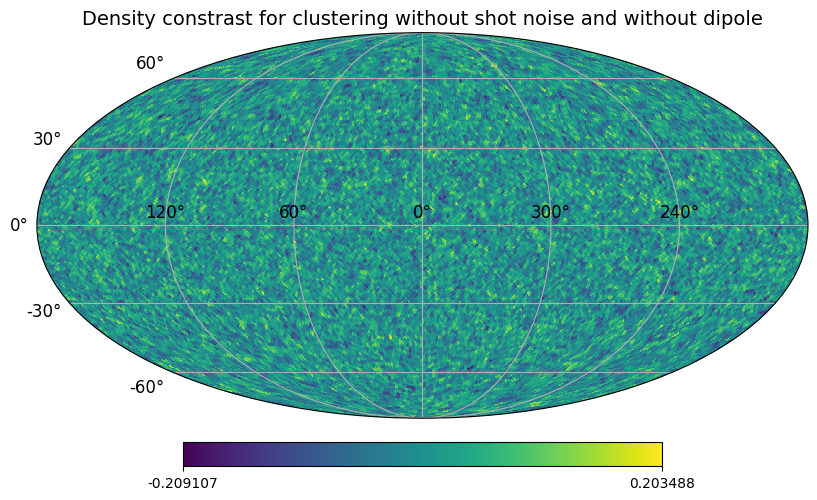

In [56]:
def get_index(data, ID, HDU='MAPS'):
    if type(ID) == np.ndarray or type(ID) == list or type(ID) == tuple:
        idx = [ get_index(data, id, HDU) for id in ID]
    else: idx = data[HDU].where(f'Map_ID == "{ID}"')
    return idx

mapID = data['FIT_NUMPY']['Map_ID'][0] #to study the first common map
idxID = get_index(data, mapID)
map = data['MAPS']['Map'][idxID][0]
title="Density constrast for clustering without shot noise and without dipole"
hp.projview(map, title=title, graticule=True, graticule_labels=True);

In [10]:
def get_dicParam_minuit(m, mapID, add_param={}, to_pandas=True):
    """Return the dictionnary of fit results useful to be saved in an external file."""
    dic_param = {"Map_ID": mapID}
    for k, v in m.values.to_dict().items():
        dic_param[k] = v
        dic_param[k + "_init"] = m.init_params[k].value
        dic_param[k + "_err"] = m.errors[k]
        dic_param[k + "_fixed"] = m.fixed[k]
        dic_param[k + "_limits"] = [m.limits[k]] #in list because if only tuple, pd.DataFrame creates a row by item of the tuple.
    dic_param["valid"] = m.valid
    for k, v in add_param.items(): dic_param[k] = v
    if to_pandas: dic_param = pd.DataFrame(dic_param)
    return dic_param

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1839 (χ²/ndof = 0.0)       │              Nfcn = 287              │
│ EDM = 2.11e-06 (Goal: 0.0002)    │            time = 2.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ A    │  0.07e-3  │  1.28e-3  │  -0.07e-3  │  0.62e-3   │    0    │    1    │       │
│ 2 │ l    │  0.17e3   │  0.27e3   │  -0.17e3   │   0.19e3   │    0    │   360   │       │
│ 3 │ b    │  89.988   │  154.377  │  -179.988  │   0.012    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.07e-3  │  0.62e-3  │  -0.17e3  │  0.19e3   │ -179.988  │   0.012   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────┐
│   │        M        A        l        b │
├───┼─────────────────────────────────────┤
│ M │        0        0        0        0 │
│ A │        0 3.37e-07 11.71e-6  0.12e-6 │
│ l │        0 11.71e-6 1.21e+05        0 │
│ b │        0  0.12e-6        0      8.4 │
└───┴─────────────────────────────────────┘

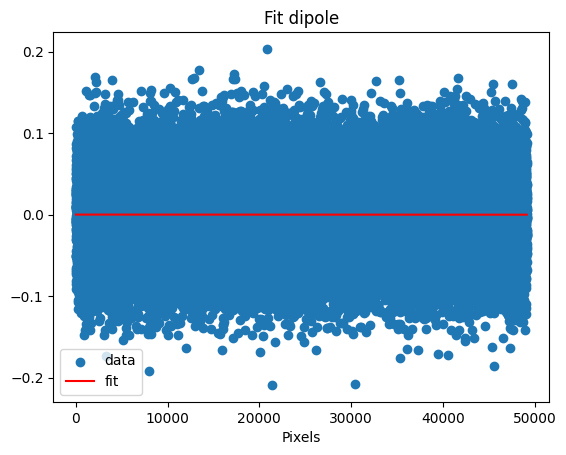

In [12]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='icrs')
init =  (0, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), fixed="M")
dic_param = get_dicParam_minuit(m, mapID, add_param={'Coord': 'spherical'})
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1839 (χ²/ndof = 0.0)       │              Nfcn = 349              │
│ EDM = 2.32e-05 (Goal: 0.0002)    │            time = 3.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ A    │  0.09e-3  │  0.94e-3  │  -0.09e-3  │  0.59e-3   │    0    │    1    │       │
│ 2 │ l    │  0.18e3   │  0.23e3   │  -0.18e3   │   0.18e3   │    0    │   360   │       │
│ 3 │ b    │    50     │    110    │    -140    │     40     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.09e-3  │  0.59e-3  │  -0.18e3  │  0.18e3   │   -140    │    40     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────────┐
│   │           M           A           l           b │
├───┼─────────────────────────────────────────────────┤
│ M │           0           0           0           0 │
│ A │           0    3.39e-07 15.43948e-3   516.02e-6 │
│ l │           0 15.43948e-3       2e+05      0.01e6 │
│ b │           0   516.02e-6      0.01e6    1.43e+05 │
└───┴─────────────────────────────────────────────────┘

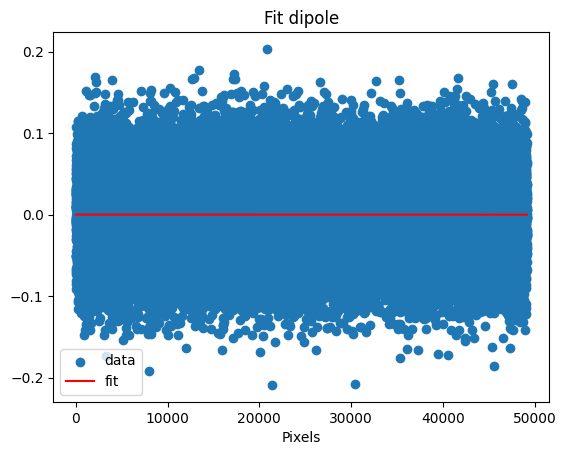

In [13]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='icrs')
init =  (0, 3, 120, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), fixed="M")
dic_param = pd.concat([dic_param, get_dicParam_minuit(m, mapID, add_param={'Coord': 'spherical'})], ignore_index=True)
m

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1839 (χ²/ndof = 0.0)       │              Nfcn = 125              │
│ EDM = 3.9e-07 (Goal: 0.0002)     │            time = 0.5 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ Dx   │  -0.1e-3  │  0.6e-3   │  -0.6e-3   │   0.6e-3   │   -1    │    1    │       │
│ 2 │ Dy   │     0     │  0.5e-3   │  -0.5e-3   │   0.5e-3   │   -1    │    1    │       │
│ 3 │ Dz   │  0.1e-3   │  0.6e-3   │  -0.6e-3   │   0.6e-3   │   -1    │    1    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          Dx           │          Dy           │          Dz           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.6e-3  │  0.6e-3   │  -0.5e-3  │  0.5e-3   │  -0.6e-3  │  0.6e-3   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌────┬─────────────────────────────────────┐
│    │        M       Dx       Dy       Dz │
├────┼─────────────────────────────────────┤
│  M │        0        0        0        0 │
│ Dx │        0  3.5e-07  0.01e-6        0 │
│ Dy │        0  0.01e-6 2.33e-07 -0.03e-6 │
│ Dz │        0        0 -0.03e-6 3.43e-07 │
└────┴─────────────────────────────────────┘

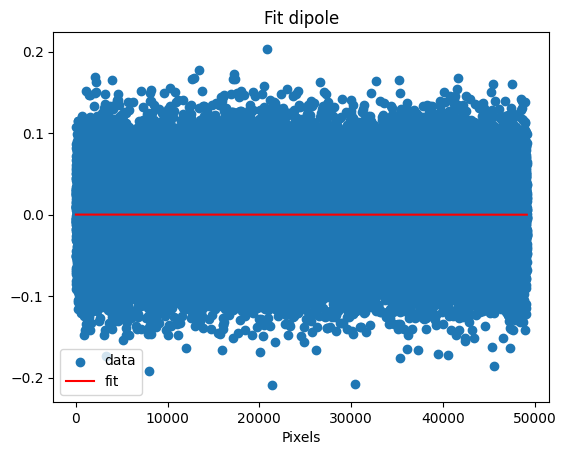

In [14]:
model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=False, frame='cartesian')
init =  (0, 0, 0, 0)
names = ("M", "Dx", "Dy", "Dz")
m = fit_dipole_err(model, map, init, names, bounds=([0, -1, -1, -1], [np.inf, 1, 1, 1]), fixed="M")
dic_param = pd.concat([dic_param, get_dicParam_minuit(m, mapID, add_param={'Coord': 'cartesian'})], ignore_index=True)
m

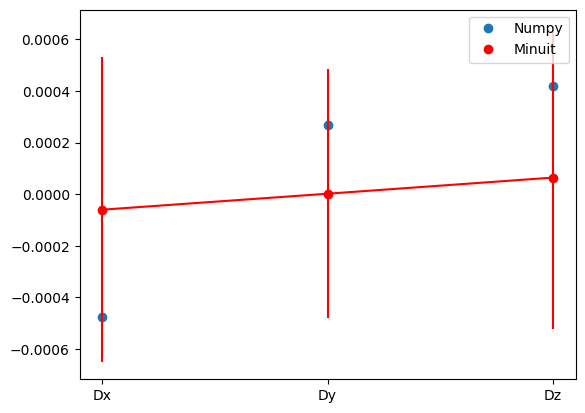

In [26]:
plt.plot(dfNumpy.set_index('Map_ID').loc[mapID][['Dx', 'Dy', 'Dz']], marker='o', linestyle='', label='Numpy')
plt.plot(dic_param.loc[2][['Dx', 'Dy', 'Dz']], marker='o', linestyle='', label='Minuit', c='r')
plt.errorbar(['Dx', 'Dy', 'Dz'], dic_param.loc[2][['Dx', 'Dy', 'Dz']], yerr=dic_param.loc[2][['Dx_err', 'Dy_err', 'Dz_err']], c='r')
plt.legend();

In [15]:
def prep_df_to_fits(df):
    data = df.copy()
    data['Coord'] = data['Coord'].astype('S9')
    for col in data.columns:
        if col.endswith('_limits'):
            mask = data[col].isna()
            data.loc[mask, col] = pd.Series([(np.nan, np.nan)] * mask.sum(), index=data.index[mask])
            data[col].replace({np.nan: (np.nan, np.nan)})
        elif col.endswith('_fixed'):
            data[col].fillna(False, inplace=True)
    return data

dic_param = prep_df_to_fits(dic_param)
dic_param

/tmp/ipykernel_21075/2528863155.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(False, inplace=True)
/tmp/ipykernel_21075/2528863155.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data[col].fillna(False, inplace=True)


,Map_ID,M,M_init,M_err,M_fixed,M_limits,A,A_init,A_err,A_fixed,...,Dy,Dy_init,Dy_err,Dy_fixed,Dy_limits,Dz,Dz_init,Dz_err,Dz_fixed,Dz_limits
0,01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,"(0.0, inf)",0.000066,1.0,0.001283,False,...,NaN,NaN,NaN,False,"(nan, nan)",NaN,NaN,NaN,False,"(nan, nan)"
1,01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,"(0.0, inf)",0.000091,1.0,0.000936,False,...,NaN,NaN,NaN,False,"(nan, nan)",NaN,NaN,NaN,False,"(nan, nan)"
2,01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,"(0.0, inf)",NaN,NaN,NaN,False,...,0.000002,0.0,0.000482,False,"(-1.0, 1.0)",0.000064,0.0,0.000585,False,"(-1.0, 1.0)"


In [108]:
def hasID_fits(data, ID, HDU='MAPS'):
    if type(ID) == np.ndarray or type(ID) == list or type(ID) == tuple:
        has_id = [hasID_fits(data, id, HDU) for id in ID]
    else: has_id = ID in data[HDU]['Map_ID'][:]
    return has_id


def get_to_save_fits(df, data, HDU='MAPS'):
    in_data = hasID_fits(data, np.array(df['Map_ID']), HDU)
    return df[~in_data]


def get_row_not_in(df1, df2=Table(data['FIT_MINUIT'].read())):
    if type(df1) == pd.DataFrame and type(df2) == pd.DataFrame:
        df_merge = df1.merge(df2, how='left', indicator=True)
        rows = df_merge[df_merge['_merge'] == 'left_only'].drop('_merge', axis=1)
    else:
        if type(df1) == pd.DataFrame: df1 = Table.from_pandas(df1)
        elif type(df2) == pd.DataFrame: df2 = Table.from_pandas(df2)
        rows = setdiff(df1, df2)
    return rows

In [16]:
dic = {k: np.array(v) for k, v in dic_param.to_dict('list').items()}
dic

{'Map_ID': array(['01KNRHFD1J62D5NP0SRDEC0FCG', '01KNRHFD1J62D5NP0SRDEC0FCG',
        '01KNRHFD1J62D5NP0SRDEC0FCG'], dtype='<U26'),
 'M': array([0., 0., 0.]),
 'M_init': array([0., 0., 0.]),
 'M_err': array([0.1, 0.1, 0.1]),
 'M_fixed': array([ True,  True,  True]),
 'M_limits': array([[ 0., inf],
        [ 0., inf],
        [ 0., inf]]),
 'A': array([6.57193879e-05, 9.05440797e-05,            nan]),
 'A_init': array([ 1.,  1., nan]),
 'A_err': array([0.00128296, 0.00093563,        nan]),
 'A_fixed': array([False, False, False]),
 'A_limits': array([[ 0.,  1.],
        [ 0.,  1.],
        [nan, nan]]),
 'l': array([172.20251294, 179.0796755 ,          nan]),
 'l_init': array([ 20., 120.,  nan]),
 'l_err': array([269.36635249, 234.17225679,          nan]),
 'l_fixed': array([False, False, False]),
 'l_limits': array([[  0., 360.],
        [  0., 360.],
        [ nan,  nan]]),
 'b': array([89.98832978, 46.16689259,         nan]),
 'b_init': array([40., 40., nan]),
 'b_err': array([154.37

In [109]:
def save_fit_minuit(dicMinuit, outputfile):
    try:
        with fitsio.FITS(outputfile, 'rw') as fits:
            fits['FIT_MINUIT'].append(dicMinuit)
    except:
        print("Coulndn't appends the new data ; using the exception.")
        with fitsio.FITS(outputfile, 'rw') as fits: #Ouvrir le fichier en mode écriture ('rw' crée ou écrase)
            fits.write(dicMinuit, extname='FIT_MINUIT')
    print("Saving complete.")

#data.close()
#save_fit_minuit(dic, outputfile)

In [92]:
test = Table(data['FIT_MINUIT'].read())
test

Map_ID,M,M_init,M_err,M_fixed,M_limits,A,A_init,A_err,A_fixed,A_limits,l,l_init,l_err,l_fixed,l_limits,b,b_init,b_err,b_fixed,b_limits,valid,Coord,Dx,Dx_init,Dx_err,Dx_fixed,Dx_limits,Dy,Dy_init,Dy_err,Dy_fixed,Dy_limits,Dz,Dz_init,Dz_err,Dz_fixed,Dz_limits
str26,float64,float64,float64,bool,float64[2],float64,float64,float64,bool,float64[2],float64,float64,float64,bool,float64[2],float64,float64,float64,bool,float64[2],bool,str9,float64,float64,float64,bool,float64[2],float64,float64,float64,bool,float64[2],float64,float64,float64,bool,float64[2]
01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,0.0 .. inf,6.571938794718704e-05,1.0,0.0012829626308812733,False,0.0 .. 1.0,172.2025129415633,20.0,269.36635249397676,False,0.0 .. 360.0,89.9883297828077,40.0,154.3772671225816,False,-90.0 .. 90.0,True,spherical,nan,nan,nan,False,nan .. nan,nan,nan,nan,False,nan .. nan,nan,nan,nan,False,nan .. nan
01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,0.0 .. inf,9.054407968689602e-05,1.0,0.0009356310207443497,False,0.0 .. 1.0,179.0796755032638,120.0,234.17225678531386,False,0.0 .. 360.0,46.16689258903281,40.0,109.02212464033062,False,-90.0 .. 90.0,True,spherical,nan,nan,nan,False,nan .. nan,nan,nan,nan,False,nan .. nan,nan,nan,nan,False,nan .. nan
01KNRHFD1J62D5NP0SRDEC0FCG,0.0,0.0,0.1,True,0.0 .. inf,nan,nan,nan,False,nan .. nan,nan,nan,nan,False,nan .. nan,nan,nan,nan,False,nan .. nan,True,cartesian,-6.020468248102895e-05,0.0,0.0005919651020845076,False,-1.0 .. 1.0,1.7029782001764778e-06,0.0,0.0004822375055840672,False,-1.0 .. 1.0,6.421841956433705e-05,0.0,0.0005854549737822537,False,-1.0 .. 1.0
